In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score


In [105]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample_submission = pd.read_csv('sample_submission.csv')

In [106]:
train.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,target,id
0,-0.098922,1.181496,3.316278,-2.411456,-0.453887,1.544592,2.226403,2.078846,-1.056295,-0.812371,4,5290
1,1.379827,-1.106794,2.549032,-2.446460,0.631218,0.653969,1.428199,0.891503,-3.258484,-1.523323,3,7596
2,-3.599969,2.147461,4.830974,-2.353533,-4.829956,-2.294152,3.360553,2.549885,0.563390,-1.561988,4,14450
3,2.989145,0.928126,-0.109679,-0.488603,2.615510,0.824107,1.451586,1.718166,-3.392987,-1.177145,3,9326
4,-1.546156,1.755276,-1.163202,0.752446,-2.065244,-0.648077,-0.348557,-1.033496,3.138165,0.882872,0,5408


In [107]:
test.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,id
0,-0.606587,0.827889,3.354539,-1.379236,-1.424324,1.583703,-0.445772,2.230222,-2.260099,-2.559024,79
1,-2.305261,-3.248349,0.012336,2.071494,-1.539818,-1.049129,-4.624029,-1.001523,-0.320027,-1.122503,8985
2,1.885282,-1.172199,-1.488945,2.296094,3.165724,0.145344,-1.805288,1.457944,-3.312764,-1.073812,12388
3,-1.579993,-0.494903,-3.248159,3.426768,-0.598569,0.292606,-4.600781,-2.062530,3.110100,1.148110,28
4,-2.350154,-1.860686,0.154958,1.579998,-2.521120,0.082557,-5.050385,-1.256080,0.326286,-1.489193,14125


In [108]:
sample_submission.head()

,id,target
0,79,0
1,8985,0
2,12388,0
3,28,0
4,14125,0


In [ ]:
from sklearn.model_selection import train_test_split

X = train.drop(['id', 'target'], axis=1)
y = train['target']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)



In [110]:
X.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10
0,-0.098922,1.181496,3.316278,-2.411456,-0.453887,1.544592,2.226403,2.078846,-1.056295,-0.812371
1,1.379827,-1.106794,2.549032,-2.446460,0.631218,0.653969,1.428199,0.891503,-3.258484,-1.523323
2,-3.599969,2.147461,4.830974,-2.353533,-4.829956,-2.294152,3.360553,2.549885,0.563390,-1.561988
3,2.989145,0.928126,-0.109679,-0.488603,2.615510,0.824107,1.451586,1.718166,-3.392987,-1.177145
4,-1.546156,1.755276,-1.163202,0.752446,-2.065244,-0.648077,-0.348557,-1.033496,3.138165,0.882872


In [111]:
y.head()

0    4
1    3
2    4
3    3
4    0
Name: target, dtype: int64

In [112]:
import matplotlib.pyplot as plt

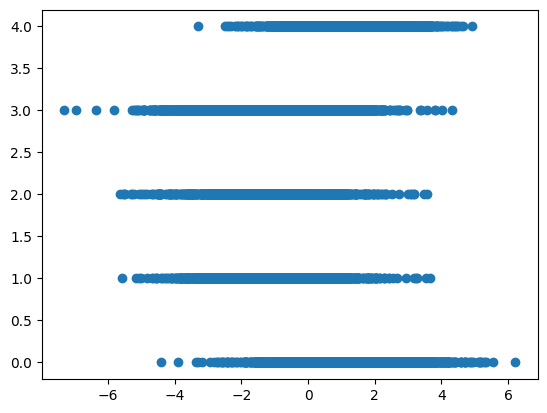

In [113]:
plt.scatter(X.iloc[:, 1], y)

In [114]:
y.unique()

array([4, 3, 0, 1, 2])

In [133]:
from sklearn.svm import SVC

model = SVC(kernel='rbf', C=45).fit(X_train, y_train)
y_pred_val = model.predict(X_val)
accuracy_score(y_val, y_pred_val)

0.9575

In [135]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

clf = MLPClassifier(hidden_layer_sizes=(10, 10, 10, 10, 10), activation='relu', solver='adam', max_iter=100000, random_state=42)
clf.fit(X_train, y_train)


y_pred_val = clf.predict(X_val)
accuracy = accuracy_score(y_val, y_pred_val)
print(f"Accuracy: {accuracy:.5f}")

Accuracy: 0.94583


In [162]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(n_estimators=70, random_state=42)
model.fit(X_train, y_train)
y_pred_val = model.predict(X_val)
accuracy = accuracy_score(y_val, y_pred_val)
print(f"Accuracy: {accuracy:.5f}")

Accuracy: 0.94250


In [154]:
from xgboost import XGBClassifier

model = XGBClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred_val = model.predict(X_val)
accuracy = accuracy_score(y_val, y_pred_val)
print(f"Accuracy: {accuracy:.5f}")

Accuracy: 0.94000


In [151]:
pd.DataFrame({"id": test['id'], "target": model.predict(test.drop('id', axis=1))}).to_csv('submission_Мухоморы.csv', index=False)

In [147]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

model = KNeighborsClassifier(n_neighbors=15)
model.fit(X_train_scaled, y_train)
y_pred_val = model.predict(X_val_scaled)
accuracy = accuracy_score(y_val, y_pred_val)
print(f"Accuracy: {accuracy:.5f}")

Accuracy: 0.94375


In [164]:
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(hidden_layer_sizes=(50,), max_iter=10000, random_state=42)
model.fit(X_train, y_train)
y_pred_val = model.predict(X_val)
accuracy = accuracy_score(y_val, y_pred_val)
print(f"Accuracy: {accuracy:.5f}")

Accuracy: 0.95250
